# 09 · Fuentes externas: macroeconomía y crédito regional

Se utiliza `data/fuentes_datos_externos_glamour.xlsx` para comparar indicadores externos con el ensemble transaccional. **Parámetros fijos; no se ejecuta Optuna.** La base conserva logística con 36 meses, XGBoost con toda la historia permitida y ponderación 50/50.

La entrega contiene series revisadas al 20 de septiembre de 2026, sin fechas históricas de publicación ni versiones anteriores. Se aplica un rezago supuesto de **tres meses**. La prueba es exploratoria y no acredita disponibilidad real de cada valor en su fecha histórica. No se reemplaza el modelo existente.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').exists():
    raise FileNotFoundError('Abrir dentro del repositorio')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
OUT = ROOT / 'reports/external_features_v1'
from scripts.external_features_ablation import WORKBOOK, prepare_sources, attach_sources, run
from scripts.master_features_ablation import development_data
from scripts.temporal_optuna import digest
protocol = json.loads((OUT / 'protocol.json').read_text())
assert digest(WORKBOOK) == protocol['workbook_sha256']
print('Excel:', WORKBOOK.name, '| Rezago supuesto:', protocol['lag_months_assumed'], 'meses')

Matplotlib is building the font cache; this may take a moment.


Excel: fuentes_datos_externos_glamour.xlsx | Rezago supuesto: 3 meses


## 1. Fuentes y vínculo temporal

Las series nacionales se vinculan por mes. Para crédito regional también se usa el departamento normalizado, conservando Callao separado de Lima. Se transforma el saldo en variación interanual dentro del departamento; el saldo bruto no entra al modelo.

La clave `mes_ref` del Excel corresponde al período económico, no a la fecha de publicación. Los porcentajes mantienen la escala original: 4,35 significa 4,35 %.

In [2]:
macro, regional, macro_columns = prepare_sources(WORKBOOK)
display(macro.head())
display(regional.head())
pool, folds = development_data()
joined = attach_sources(pool, macro, regional, protocol['lag_months_assumed'])
display(joined[['mes_obs', 'external_ref_month']].drop_duplicates().sort_values('mes_obs').tail(8))
display(pd.read_csv(OUT / 'coverage.csv'))
print('Solo se usa desarrollo hasta:', joined.mes_obs.max().date())

,mes_ref,ipc_nacional_base_dic2021_100,inflacion_nacional_mensual_pct,inflacion_nacional_var12_pct,comercio_var12_pct,pbi_var12_pct,expect_economia_3m_indice,expect_demanda_3m_indice,empleo_formal_var12_pct,ingreso_formal_nominal_var12_pct,tipo_cambio_soles_usd,credito_consumo_var12_pct
0,2016-01-01,83.8968,0.42,4.35,2.575400,3.541027,42.514124,50.842697,3.400724,4.072925,3.438650,13.961318
1,2016-02-01,84.0360,0.17,4.22,3.400820,6.424334,46.675900,53.462604,3.393112,4.214700,3.506957,14.083728
2,2016-03-01,84.5442,0.60,4.14,2.358068,3.549407,46.398892,57.005495,3.847166,-0.634649,3.406929,12.631625
3,2016-04-01,84.5581,0.02,3.78,3.108007,2.766479,54.166667,61.048159,2.482203,0.254521,3.301100,11.801690
4,2016-05-01,84.6516,0.11,3.46,2.292845,4.873504,53.443526,58.016304,2.666924,3.297837,3.334682,11.205922


,mes_ref,departamento_fuente,codigo_bcrp,credito_total_millones_soles,department_key,credit_year_ago,credito_regional_var12_pct
0,2016-01-01,Amazonas,RD13562DM,353.856312,amazonas,NaN,NaN
1,2016-02-01,Amazonas,RD13562DM,359.978250,amazonas,NaN,NaN
2,2016-03-01,Amazonas,RD13562DM,362.648190,amazonas,NaN,NaN
3,2016-04-01,Amazonas,RD13562DM,368.694624,amazonas,NaN,NaN
4,2016-05-01,Amazonas,RD13562DM,375.214382,amazonas,NaN,NaN


,mes_obs,external_ref_month
88,2024-06-01,2024-03-01
89,2024-07-01,2024-04-01
90,2024-08-01,2024-05-01
91,2024-09-01,2024-06-01
92,2024-10-01,2024-07-01
722,2024-11-01,2024-08-01
246,2024-12-01,2024-09-01
22,2025-01-01,2024-10-01


,partition,rows,missing_region_key,missing_regional_growth,missing_macro_rows
0,development,28311,70,2088,0
1,validation,4379,3,3,0


Solo se usa desarrollo hasta: 2025-01-01


## 2. Variantes y ejecución

Se prueban inflación interanual, crecimiento del comercio, expectativas de demanda, crecimiento del crédito regional, las cuatro juntas y todos los indicadores disponibles. Las 42 variables transaccionales permanecen en todas las variantes. Los faltantes regionales se imputan dentro del entrenamiento e incluyen un indicador de ausencia.

El modo de lectura no entrena. Para ejecutar o reanudar las variantes con el mismo protocolo, activar `EJECUTAR`. Cambiar el Excel o el rezago requiere otro directorio de resultados.

In [3]:
variables = json.loads((OUT / 'variables.json').read_text())
display(pd.DataFrame([{'variante': key, 'variables_externas': ', '.join(value) or 'Ninguna'}
                      for key, value in variables['variants'].items()]))
display(pd.DataFrame(json.loads((OUT / 'parameters.json').read_text())).T)
EJECUTAR = False
if EJECUTAR:
    import fcntl
    with (OUT / 'runner.lock').open('w') as lock:
        fcntl.flock(lock, fcntl.LOCK_EX | fcntl.LOCK_NB)
        run(workbook=WORKBOOK, output=OUT, lag=protocol['lag_months_assumed'], threads=4)

,variante,variables_externas
0,transaccional,Ninguna
1,mas_inflacion,inflacion_nacional_var12_pct
2,mas_comercio,comercio_var12_pct
3,mas_expectativas_demanda,expect_demanda_3m_indice
4,mas_credito_regional,credito_regional_var12_pct
5,cuatro_fuentes,"inflacion_nacional_var12_pct, comercio_var12_p..."
6,todos_externos,"ipc_nacional_base_dic2021_100, inflacion_nacio..."


,features,balance,C,l1_ratio,n_estimators,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,gamma
logreg,all,True,1.224031,0.588628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
xgboost,all,True,NaN,NaN,1000,3,0.006249,74.688833,0.797182,0.915885,3.308422,13.982859,2.486928


## 3. Resultados

El AUC principal promedia los cuatro bloques temporales. También se promedia el AUC de cada mes: un indicador nacional puede ordenar meses diferentes sin distinguir mejor a las vendedoras dentro de un mes. El top 10/20/30 % se selecciona siempre dentro de cada mes.

,variant,n_external_variables,auc_mean,auc_std,ap_mean,precision_top10,recall_top10,lift_top10,precision_top20,recall_top20,lift_top20,precision_top30,recall_top30,lift_top30,auc_monthly_mean,delta_auc,delta_auc_monthly
0,mas_comercio,1,0.79005,0.00672,0.59833,0.68213,0.21826,2.24996,0.62874,0.40609,2.06693,0.57657,0.55902,1.89481,0.79046,0.00017,0.00008
1,cuatro_fuentes,4,0.78990,0.00660,0.59779,0.68677,0.21975,2.26592,0.62759,0.40535,2.06580,0.57274,0.55531,1.88474,0.79050,0.00002,0.00012
2,transaccional,0,0.78988,0.00645,0.59621,0.68445,0.21901,2.25675,0.62759,0.40535,2.06519,0.57351,0.55605,1.88477,0.79038,0.00000,0.00000
3,mas_inflacion,1,0.78984,0.00629,0.59656,0.68445,0.21901,2.25379,0.63103,0.40757,2.07596,0.57657,0.55902,1.89405,0.79046,-0.00004,0.00007
4,mas_credito_regional,1,0.78966,0.00659,0.59601,0.68445,0.21901,2.24981,0.62644,0.40460,2.06067,0.57504,0.55754,1.89231,0.79037,-0.00022,-0.00002
5,mas_expectativas_demanda,1,0.78962,0.00638,0.59555,0.68677,0.21975,2.26340,0.62644,0.40460,2.05967,0.57504,0.55754,1.89201,0.78996,-0.00026,-0.00042
6,todos_externos,12,0.78947,0.00583,0.58912,0.68910,0.22049,2.28042,0.63103,0.40757,2.07489,0.57427,0.55679,1.88801,0.79052,-0.00041,0.00014


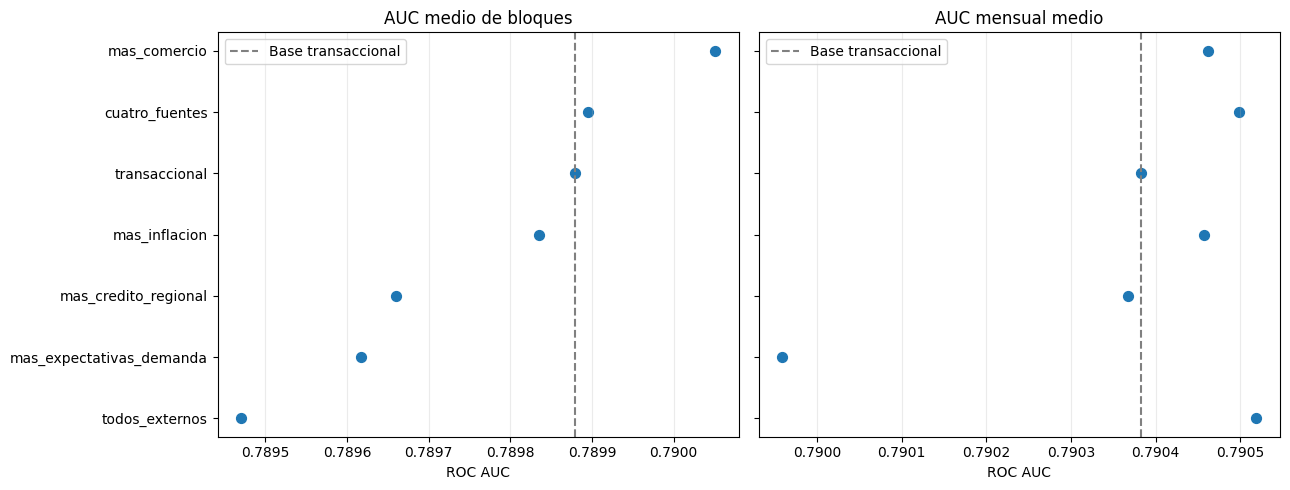

In [4]:
comparison = pd.read_csv(OUT / 'comparison.csv')
display(comparison.round(5))
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ordered = comparison.sort_values('auc_mean')
for ax, column, title in zip(axes, ['auc_mean', 'auc_monthly_mean'], ['AUC medio de bloques', 'AUC mensual medio']):
    ax.scatter(ordered[column], ordered.variant, s=50)
    base = comparison.loc[comparison.variant == 'transaccional', column].iloc[0]
    ax.axvline(base, linestyle='--', color='gray', label='Base transaccional')
    ax.set(title=title, xlabel='ROC AUC')
    ax.grid(axis='x', alpha=.25)
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Consistencia por período y componente

In [5]:
blocks = pd.read_csv(OUT / 'block_metrics.csv')
auc = blocks.pivot(index='variant', columns='fold', values='auc')
display(auc.round(5))
display(auc.subtract(auc.loc['transaccional']).round(5))
components = pd.read_csv(OUT / 'component_metrics.csv')
display(components.pivot(index='variant', columns='model', values='auc_mean').round(5))
monthly = pd.read_csv(OUT / 'monthly_metrics.csv')
display(monthly[(monthly.variant == comparison.iloc[0].variant) & (monthly.top_fraction == .2)].round(4))

fold,0,1,2,3
variant,,,,
cuatro_fuentes,0.78375,0.79592,0.78287,0.79704
mas_comercio,0.78466,0.79552,0.78222,0.79781
mas_credito_regional,0.78457,0.79507,0.78180,0.79720
mas_expectativas_demanda,0.78466,0.79516,0.78200,0.79665
mas_inflacion,0.78528,0.79485,0.78211,0.79710
todos_externos,0.78359,0.79213,0.78440,0.79776
transaccional,0.78535,0.79493,0.78187,0.79737


fold,0,1,2,3
variant,,,,
cuatro_fuentes,-0.00160,0.00098,0.00100,-0.00033
mas_comercio,-0.00069,0.00058,0.00035,0.00045
mas_credito_regional,-0.00078,0.00014,-0.00006,-0.00017
mas_expectativas_demanda,-0.00069,0.00023,0.00013,-0.00072
mas_inflacion,-0.00007,-0.00009,0.00025,-0.00027
todos_externos,-0.00176,-0.00280,0.00253,0.00039
transaccional,0.00000,0.00000,0.00000,0.00000


model,logreg,xgboost
variant,,
cuatro_fuentes,0.78752,0.78813
mas_comercio,0.78760,0.78811
mas_credito_regional,0.78738,0.78853
mas_expectativas_demanda,0.78752,0.78792
mas_inflacion,0.78761,0.78831
todos_externos,0.78660,0.78769
transaccional,0.78763,0.78834


,month,top_fraction,n,n_top,positives,tp,precision,recall,lift,auc,variant
97,2023-10-01,0.2,301,60,77,31,0.5167,0.4026,2.0197,0.7823,mas_comercio
100,2023-11-01,0.2,361,72,139,47,0.6528,0.3381,1.6953,0.7588,mas_comercio
103,2023-12-01,0.2,309,61,114,47,0.7705,0.4123,2.0884,0.8300,mas_comercio
106,2024-01-01,0.2,253,50,81,33,0.6600,0.4074,2.0615,0.7774,mas_comercio
109,2024-02-01,0.2,239,47,57,21,0.4468,0.3684,1.8735,0.7201,mas_comercio
112,2024-03-01,0.2,242,48,70,30,0.6250,0.4286,2.1607,0.8159,mas_comercio
115,2024-04-01,0.2,258,51,82,36,0.7059,0.4390,2.2209,0.8170,mas_comercio
118,2024-05-01,0.2,267,53,76,33,0.6226,0.4342,2.1874,0.8153,mas_comercio
121,2024-06-01,0.2,250,50,56,23,0.4600,0.4107,2.0536,0.7979,mas_comercio
124,2024-07-01,0.2,283,56,73,36,0.6429,0.4932,2.4922,0.8288,mas_comercio


## 5. Informe y límites de interpretación

In [6]:
display(Markdown((ROOT / '07_results/ablacion_fuentes_externas.md').read_text()))

# Evaluación exploratoria de fuentes externas

Se utilizaron las tablas del Excel `data/fuentes_datos_externos_glamour.xlsx`:
120 meses con 11 indicadores nacionales y 3.000 observaciones de crédito regional,
25 ámbitos (24 departamentos y Callao), entre enero de 2016 y diciembre de 2025.

## Resultados

La mayor media de AUC se obtuvo añadiendo comercio: **0,79005**, frente a **0,78988** de la base (**+0,00017**). Mejoró en tres de los cuatro bloques, con diferencias pequeñas. No se ha demostrado una mejora relevante o estadísticamente significativa; se mantiene el modelo previo.

Con todos los indicadores, el AUC por bloques fue **0,78947**, pero el AUC mensual medio pasó de **0,79038 a 0,79052**. En el top 10 % se identificaron **297 casos frente a 295**, sobre 431 observaciones priorizadas. En el top 20 %, **549 frente a 546**, sobre 870. Los criterios de evaluación no se mueven todos en el mismo sentido.

| variant                  |   auc_mean |   delta_auc |   auc_monthly_mean |   delta_auc_monthly |   precision_top10 |   recall_top10 |   lift_top10 |
|:-------------------------|-----------:|------------:|-------------------:|--------------------:|------------------:|---------------:|-------------:|
| mas_comercio             |    0.79005 |     0.00017 |            0.79046 |             0.00008 |           0.68213 |        0.21826 |      2.24996 |
| cuatro_fuentes           |    0.78990 |     0.00002 |            0.79050 |             0.00012 |           0.68677 |        0.21975 |      2.26592 |
| transaccional            |    0.78988 |     0.00000 |            0.79038 |             0.00000 |           0.68445 |        0.21901 |      2.25675 |
| mas_inflacion            |    0.78984 |    -0.00004 |            0.79046 |             0.00007 |           0.68445 |        0.21901 |      2.25379 |
| mas_credito_regional     |    0.78966 |    -0.00022 |            0.79037 |            -0.00002 |           0.68445 |        0.21901 |      2.24981 |
| mas_expectativas_demanda |    0.78962 |    -0.00026 |            0.78996 |            -0.00042 |           0.68677 |        0.21975 |      2.26340 |
| todos_externos           |    0.78947 |    -0.00041 |            0.79052 |             0.00014 |           0.68910 |        0.22049 |      2.28042 |

## AUC por bloque

| variant                  |       0 |       1 |       2 |       3 |
|:-------------------------|--------:|--------:|--------:|--------:|
| cuatro_fuentes           | 0.78375 | 0.79592 | 0.78287 | 0.79704 |
| mas_comercio             | 0.78466 | 0.79552 | 0.78222 | 0.79781 |
| mas_credito_regional     | 0.78457 | 0.79507 | 0.78180 | 0.79720 |
| mas_expectativas_demanda | 0.78466 | 0.79516 | 0.78200 | 0.79665 |
| mas_inflacion            | 0.78528 | 0.79485 | 0.78211 | 0.79710 |
| todos_externos           | 0.78359 | 0.79213 | 0.78440 | 0.79776 |
| transaccional            | 0.78535 | 0.79493 | 0.78187 | 0.79737 |

## Comparación y variables

Ensemble 50/50 de logística (36 meses) y XGBoost (historia permitida completa),
42 variables transaccionales y los parámetros ya exportados. **No se ejecutó Optuna.**
Cuatro bloques entre octubre de 2023 y enero de 2025, gap de seis meses,
4.379 observaciones de validación. La base reutiliza predicciones verificadas con los
mismos datos, parámetros y versiones. No se añadieron sexo, edad, antigüedad ni códigos
de ubicación como predictores; departamento solo se utiliza para vincular crédito.

- `transaccional`: base sin variables externas.
- `mas_inflacion`: `inflacion_nacional_var12_pct`.
- `mas_comercio`: `comercio_var12_pct`.
- `mas_expectativas_demanda`: `expect_demanda_3m_indice`.
- `mas_credito_regional`: `credito_regional_var12_pct`.
- `cuatro_fuentes`: `inflacion_nacional_var12_pct`, `comercio_var12_pct`, `expect_demanda_3m_indice`, `credito_regional_var12_pct`.
- `todos_externos`: `ipc_nacional_base_dic2021_100`, `inflacion_nacional_mensual_pct`, `inflacion_nacional_var12_pct`, `comercio_var12_pct`, `pbi_var12_pct`, `expect_economia_3m_indice`, `expect_demanda_3m_indice`, `empleo_formal_var12_pct`, `ingreso_formal_nominal_var12_pct`, `tipo_cambio_soles_usd`, `credito_consumo_var12_pct`, `credito_regional_var12_pct`.

Para una observación en el mes `t`, se usa el indicador de `t−3` meses.
Crédito regional es variación porcentual interanual dentro del mismo departamento:
`100 × (saldo(t−3) / saldo(t−3−12) − 1)`; el saldo bruto no entra al modelo.
Callao se conserva separado de Lima. Se normalizan espacios, mayúsculas y tildes.
Los crecimientos ausentes se imputan con la mediana de cada entrenamiento y se
añade un indicador de ausencia. Los porcentajes conservan su escala: 4,35 significa 4,35 %.

## Cobertura

| partition   |   rows |   missing_region_key |   missing_regional_growth |   missing_macro_rows |
|:------------|-------:|---------------------:|--------------------------:|---------------------:|
| development |  28311 |                   70 |                      2088 |                    0 |
| validation  |   4379 |                    3 |                         3 |                    0 |

La variación anual requiere un año previo; por ello falta en algunos meses iniciales
del entrenamiento. También queda ausente cuando el departamento no se puede vincular.
La imputación nunca usa validación y no se eliminan observaciones para favorecer una variante.

## Alcance de la evidencia

- **Snapshot revisado al 20 de septiembre de 2026.** El Excel no incluye fechas de
  publicación históricas ni versiones de lo conocido en cada fecha. El rezago de 3
  meses es una hipótesis explícita, no una verificación de disponibilidad histórica.
  Esta corrida no acredita desempeño sin fuga temporal por revisiones.
- Departamento proviene del maestro actual. Su correspondencia histórica tampoco
  está garantizada; esto afecta la unión con crédito regional.
- Los indicadores nacionales son iguales para todas las vendedoras de un mes.
  Se reportan AUC mensual y priorización dentro de cada mes para distinguir una mejora
  de ranking individual de una mejora en la comparación entre meses. Las filas no
  equivalen a observaciones macroeconómicas independientes.
- Las validaciones ya se utilizaron para seleccionar modelos. Los resultados son
  exploratorios, con parámetros fijos, sin evaluación final independiente ni demostración
  de significancia estadística. No se reemplazó el modelo anterior.
- Las fuentes F08–F13 del catálogo no contienen tablas de datos en el archivo y no se
  incorporaron. Se utilizaron únicamente las dos tablas efectivamente entregadas.

## Reproducibilidad

Artefactos en `reports/external_features_v1`: protocolo con hashes, parámetros, variables,
cobertura, tablas fuente, dataset vinculado, predicciones por fold y métricas.
Ejecutar `python -m scripts.external_features_ablation`; un bloqueo evita ejecuciones
simultáneas y el manifiesto impide mezclar protocolos. Las predicciones terminadas se reutilizan.
El Excel original permanece intacto.

Verificación: la extracción se contrastó celda a celda con Artifact Tool. Las pruebas revisan la unión por mes rezagado, la separación Lima/Callao, la variación anual por mes exacto, claves duplicadas y la exclusión de columnas no autorizadas como predictores.

[Notebook ejecutable de resultados](../05_modelling/09_fuentes_externas.ipynb).
